Pipeline Structure:
- Frozen VAE (Stable Diffusion's KL-Autoencoder)
- CLIP text encoder for conditioning
- U-Net for latent space denoising
- Linear noise schedule

Data Handling:
- Balanced class sampling (food/drink/inside/outside)
- Proper image normalization ([-1, 1])
- CLIP tokenization with padding/truncation

Training Loop:
- Latent diffusion with MSE noise prediction
- Validation loss tracking

Evaluation:
- FID and Inception Score metrics
- Image grid visualization

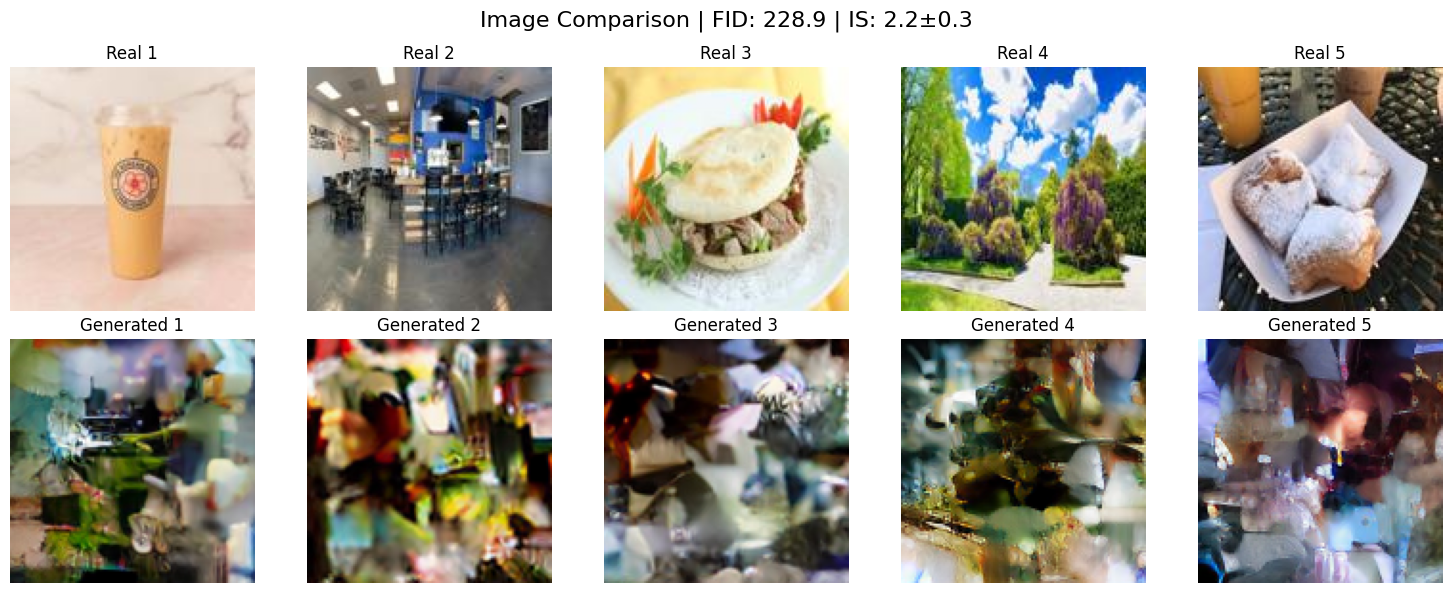

- An FID of 228.9 is very high, indicating that the generated images are not similar to the real images in terms of features extracted by Inception v3.
- An IS of 2.2 is very low. It indicates that the generated images are not diverse and the Inception model does not assign high confidence to any particular class.

In [ ]:
!pip install torchmetrics torch-fidelity
import os, math, heapq, torch, torch.nn as nn, torch.nn.functional as F
import torchvision.utils as tv_utils
from torch.utils.data import Dataset, DataLoader, random_split
from torchmetrics.image.fid import FrechetInceptionDistance
from torchmetrics.image.inception import InceptionScore
from torchvision import transforms
from PIL import Image
import pandas as pd
from tqdm import tqdm
from PIL import Image
import matplotlib.pyplot as plt

from diffusers import AutoencoderKL               # VAE (frozen)
from transformers import CLIPTokenizer, CLIPTextModel

In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print(device)

cuda


In [ ]:
# Paths & hyper-params
image_dir   = "/content/Assignment4/sampled/128_pix/split_photos_128/train"
caption_file = "/content/Assignment4/sampled/128_pix/128train_df_with_captions.csv"

In [ ]:
# Parameters
image_size            = 128
batch_size            = 32
num_epochs            = 5
learning_rate         = 2e-4
sample_labels         = ["food", "drink", "inside", "outside"]
num_samples_per_class = 500
val_split             = 0.2

# diffusion schedule (classic linear β)
timesteps = 1000
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
betas     = torch.linspace(1e-4, 0.02, timesteps)
alphas           = 1. - betas
alphas_cumprod   = torch.cumprod(alphas, dim=0)

**Dataset**:
   - `YelpCaptionedDataset` loads the captions and images. It balances the dataset by sampling a fixed number (500) per class (food, drink, inside, outside).
   - Images are transformed: resized, normalized to [-1,1].
   - Captions are tokenized with CLIP tokenizer.

In [ ]:
class YelpCaptionedDataset(Dataset):
    def __init__(self,
                 caption_csv, image_root, transform, tokenizer,
                 max_samples_per_class=500):
        df = pd.read_csv(caption_csv)
        df = df[df["label"].isin(sample_labels)]

        print("\n▶ Original label distribution")
        print(df["label"].value_counts())

        df = (df.groupby("label")
                .apply(lambda x: x.sample(
                    n=min(max_samples_per_class, len(x)),
                    random_state=42))
                .reset_index(drop=True))

        print("\n Balanced sample ({} each)".format(max_samples_per_class))
        print(df["label"].value_counts())

        self.df         = df
        self.image_root = image_root
        self.transform  = transform
        self.tokenizer  = tokenizer

    def __len__(self): return len(self.df)

    def __getitem__(self, idx):
        row        = self.df.iloc[idx]
        img_path   = os.path.join(self.image_root,
                                  row["label"],
                                  f"{row['photo_id']}.jpg")
        # Verify image exists
        if not os.path.exists(img_path):
          print(f"Warning: Missing image {img_path}")
          # Return a placeholder or skip
          return self[(idx + 1) % len(self)]

        #print(f"Attempting to open: {img_path}")
        img        = self.transform(Image.open(img_path).convert("RGB"))
        toks       = self.tokenizer(row["caption"],
                                    padding="max_length",
                                    truncation=True,
                                    max_length=77,
                                    return_tensors="pt")
        return {"pixel_values": img,
                "input_ids":     toks.input_ids.squeeze(0),
                "caption":       row["caption"]} # Return raw caption text

transform = transforms.Compose([
    transforms.Resize((image_size, image_size)),
    transforms.ToTensor(),
    transforms.Normalize([0.5]*3, [0.5]*3)
])

**VAE and Text Encoder**:
   - The VAE (AutoencoderKL) is loaded from "stabilityai/sd-vae-ft-mse" and set to evaluation mode (frozen).
   - The CLIP tokenizer and text encoder are loaded. The text encoder is also set to `eval` mode and its weights are frozen.

**Model Architecture**:
   - `SinusoidalPosEmb`: Implements sinusoidal positional embeddings for the diffusion timestep.
   - `SimpleUNet`: A small UNet that takes noisy latents, time embedding, and text embedding to predict the noise. The text embedding is projected to match the condition dimension and added to the time embedding. The UNet has an encoder, a middle block, and a decoder.

**Diffusion Helpers**:
   - `q_sample_latent`: Performs the forward diffusion step in the latent space (adds noise to the latent at a given timestep).
   - `p_sample_loop`: The reverse diffusion process (sampling). It starts from Gaussian noise and iteratively denoises using the UNet. The text prompt is encoded by CLIP and used as conditioning. The output is decoded by the VAE to get an image.

**Training Loop**:
   - The UNet is trained to predict the noise added in the forward diffusion process.
   - For each batch, the images are encoded into latents by the VAE (and scaled by 0.18215, as in Stable Diffusion).

In [ ]:
from diffusers import AutoencoderKL
vae = AutoencoderKL.from_pretrained("stabilityai/sd-vae-ft-mse").to(device)
vae.eval()  # Don't train the VAE

In [ ]:
tokenizer     = CLIPTokenizer.from_pretrained("openai/clip-vit-base-patch32")

full_ds       = YelpCaptionedDataset(caption_file, image_dir,
                                     transform, tokenizer,
                                     max_samples_per_class=num_samples_per_class)
val_sz        = int(val_split * len(full_ds))
train_ds, val_ds = random_split(full_ds, [len(full_ds)-val_sz, val_sz])
train_loader  = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
val_loader    = DataLoader(val_ds,   batch_size=batch_size)


▶ Original label distribution
label
food       10235
inside      8927
outside     7460
drink       6796
Name: count, dtype: int64

▶ Balanced sample (500 each)
label
drink      500
food       500
inside     500
outside    500
Name: count, dtype: int64


/tmp/ipython-input-26-595644746.py:12: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(


In [ ]:
class SinusoidalPosEmb(nn.Module):
    def __init__(self, dim): super().__init__(); self.dim = dim
    def forward(self, t):
        half = self.dim//2
        emb  = math.log(10000)/ (half-1)
        emb  = torch.exp(torch.arange(half, device=t.device)*-emb)
        emb  = t[:,None]*emb[None,:]
        return torch.cat([emb.sin(), emb.cos()], dim=-1)   # [B,dim]
class SimpleUNet(nn.Module):
    def __init__(self, text_embed_dim, time_emb_dim=64, cond_dim=128):
        super().__init__()
        self.time_mlp = nn.Sequential(
            SinusoidalPosEmb(time_emb_dim),
            nn.Linear(time_emb_dim, cond_dim),
            nn.ReLU())
        self.text_proj = nn.Linear(text_embed_dim, cond_dim)

        self.encoder = nn.Sequential(
            nn.Conv2d(4+cond_dim,128,3,1,1), nn.BatchNorm2d(128), nn.ReLU(),
            nn.Conv2d(128,256,3,1,1),        nn.BatchNorm2d(256), nn.ReLU())
        self.middle  = nn.Sequential(
            nn.Conv2d(256,256,3,1,1),        nn.BatchNorm2d(256), nn.ReLU())
        self.decoder = nn.Sequential(
            nn.Conv2d(256,128,3,1,1),        nn.BatchNorm2d(128), nn.ReLU(),
            nn.Conv2d(128,4,3,1,1))                            # predicts ε

    def forward(self, x, t, txt):                 # x: [B,4,H/8,W/8]
        cond = self.time_mlp(t) + self.text_proj(txt)  # [B,cond_dim]
        cond = cond[:,:,None,None].expand(-1,-1,x.size(2),x.size(3))
        h    = self.encoder(torch.cat([x,cond],1))
        h    = self.middle(h)
        return self.decoder(h)

# diffusion helpers ----------------------------------------------------------
def q_sample_latent(z0, t, noise):
    """
    Forward-diffusion step in *latent* space
    z0    : clean latent  (B,4,H/8,W/8)
    t     : int64 steps   (B,)
    noise : ε ~ N(0,1)    (same shape as z0)
    """
    ac  = alphas_cumprod.to(z0.device)[t]
    ac  = ac[:, None, None, None]
    oma = 1. - ac

    return torch.sqrt(ac) * z0 + torch.sqrt(oma) * noise

@torch.no_grad()
def p_sample_loop(prompt, unet, tokenizer, text_encoder, steps=timesteps):
    """generate RGB image from text prompt"""
    unet.eval()
    text_in  = tokenizer(prompt, return_tensors="pt",
                         padding="max_length", truncation=True,
                         max_length=77).to(device)
    txt_emb = text_encoder(input_ids).pooler_output #Use pooled EOS token(CLIP expects the EOS token embedding (pooler output))

    # random latent start (B,4,H/8,W/8)
    h = w = image_size // 8
    z = torch.randn(1, 4, h, w, device=device)

    for i in reversed(range(steps)):
        t     = torch.full((1,), i, device=device, dtype=torch.long)
        eps   = unet(z, t.float(), txt_emb)

        beta  = betas[i];   alpha = alphas[i];   a_hat = alphas_cumprod[i]
        noise = torch.randn_like(z) if i > 0 else 0
        z     = (1/torch.sqrt(alpha)) * (
                  z - ( (1-alpha) / torch.sqrt(1-a_hat) ) * eps ) + torch.sqrt(beta) * noise

    imgs = vae.decode(z / 0.18215).sample      # SD scaling constant
    return imgs.clamp(-1,1)

In [ ]:
text_encoder = CLIPTextModel.from_pretrained("openai/clip-vit-base-patch32").to(device).eval()
unet = SimpleUNet(text_embed_dim=512).to(device)
opt = torch.optim.AdamW(unet.parameters(), lr=learning_rate)

# Only track best model (no need for heap with 5 epochs)
best_val_loss = float('inf')

for ep in range(num_epochs):
    # --- Training Phase ---
    unet.train()
    epoch_train_loss = 0

    for batch in tqdm(train_loader, desc=f"Epoch {ep+1}/{num_epochs}"):
        with torch.no_grad():
            imgs_lat = vae.encode(batch["pixel_values"].to(device)).latent_dist.sample() * 0.18215
            txt_emb = text_encoder(batch["input_ids"].to(device)).pooler_output

        t = torch.randint(0, timesteps, (imgs_lat.size(0),), device=device).long()
        noise = torch.randn_like(imgs_lat)
        z_noisy = q_sample_latent(imgs_lat, t, noise)

        pred = unet(z_noisy, t.float(), txt_emb)
        loss = F.mse_loss(pred, noise)

        opt.zero_grad()
        loss.backward()
        opt.step()
        epoch_train_loss += loss.item()

    print(f"  Mean train loss: {epoch_train_loss/len(train_loader):.4f}")

    # --- Validation Phase ---
    unet.eval()
    with torch.no_grad():
        val_batch = next(iter(val_loader))
        v_lat = vae.encode(val_batch["pixel_values"].to(device)).latent_dist.sample() * 0.18215
        v_emb = text_encoder(val_batch["input_ids"].to(device)).pooler_output
        vt = torch.randint(0, timesteps, (v_lat.size(0),), device=device).long()
        v_noise = torch.randn_like(v_lat)
        v_noisy = q_sample_latent(v_lat, vt, v_noise)
        v_pred = unet(v_noisy, vt.float(), v_emb)
        val_loss = F.mse_loss(v_pred, v_noise).item()

    print(f"  Val loss: {val_loss:.4f}")

    # --- Simplified Saving Logic ---
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        # Only save model weights (no optimizer/epoch needed for 5 epochs)
        torch.save(unet.state_dict(), "best_unet.pt")
        print(f"  New best model saved (val_loss={val_loss:.4f})")

# Final report
print(f"\nTraining completed. Best val_loss: {best_val_loss:.4f}")

Epoch 1/5: 100%|██████████| 50/50 [00:25<00:00,  1.95it/s]


  Mean train loss: 0.5418
  Val loss: 0.3197
  New best model saved (val_loss=0.3197)


Epoch 2/5: 100%|██████████| 50/50 [00:24<00:00,  2.07it/s]


  Mean train loss: 0.3149
  Val loss: 0.3559


Epoch 3/5: 100%|██████████| 50/50 [00:23<00:00,  2.15it/s]


  Mean train loss: 0.2751
  Val loss: 0.2310
  New best model saved (val_loss=0.2310)


Epoch 4/5: 100%|██████████| 50/50 [00:24<00:00,  2.07it/s]


  Mean train loss: 0.2379
  Val loss: 0.1965
  New best model saved (val_loss=0.1965)


Epoch 5/5: 100%|██████████| 50/50 [00:25<00:00,  1.96it/s]


  Mean train loss: 0.2409
  Val loss: 0.2967

Training completed. Best val_loss: 0.1965


In [ ]:
from torchmetrics.image.fid import FrechetInceptionDistance
fid = FrechetInceptionDistance(feature=2048).cuda()   # or .to(device)
print("FID OK")


FID OK


In [ ]:
# Define evaluation parameters
N_METRIC = 500   # Images for FID/IS (good statistical estimate)
N_PREVIEW = 5    # Images for side-by-side grid
BATCH_SIZE_GEN = 16  # Batch size for generation
STEPS = 500       # Sampling steps

# Move diffusion schedule parameters to device
betas = betas.to(device)
alphas = alphas.to(device)
alphas_cumprod = alphas_cumprod.to(device)

@torch.no_grad()
def p_sample_loop_batch(text_embeddings, unet, steps=STEPS):
    """Batch version of sampling function"""
    n = text_embeddings.size(0)
    h = w = image_size // 8
    z = torch.randn(n, 4, h, w, device=device)

    for i in reversed(range(steps)):
        t = torch.full((n,), i, device=device, dtype=torch.long)
        eps = unet(z, t.float(), text_embeddings)

        beta = betas[i]
        alpha = alphas[i]
        a_hat = alphas_cumprod[i]

        noise = torch.randn_like(z) if i > 0 else 0
        z = (1 / torch.sqrt(alpha)) * (
            z - ((1 - alpha) / torch.sqrt(1 - a_hat)) * eps
        ) + torch.sqrt(beta) * noise

    imgs = vae.decode(z / 0.18215).sample
    return imgs.clamp(-1, 1)

@torch.no_grad()
def generate_images(captions, unet, tokenizer, text_encoder, steps=STEPS, batch_size=BATCH_SIZE_GEN):
    """Generate images matching validation captions in batches"""
    # Process in batches to avoid OOM
    all_images = []

    for i in range(0, len(captions), batch_size):
        batch_captions = captions[i:i+batch_size]

        # Tokenize batch
        text_inputs = tokenizer(
            batch_captions,
            padding="max_length",
            truncation=True,
            max_length=77,
            return_tensors="pt"
        ).to(device)

        # Get embeddings
        text_embeddings = text_encoder(text_inputs.input_ids).pooler_output

        # Generate images
        images = p_sample_loop_batch(text_embeddings, unet, steps=steps)
        all_images.append(images)

    return torch.cat(all_images)

In [ ]:
# Load best model for evaluation
print("Loading best model for evaluation...")
unet.load_state_dict(torch.load("best_unet.pt"))
unet.eval()

print("Preparing validation data...")
val_indices = torch.randperm(len(val_ds))[:N_METRIC].tolist()

# Directly get images and captions from the validation dataset
real_imgs_all = torch.stack([val_ds[i]["pixel_values"] for i in val_indices]).to(device)
captions = [val_ds[i]["caption"] for i in val_indices]  # Now accessible

# Generate matching fake images
print(f"Generating {N_METRIC} images...")
fake_imgs_all = generate_images(
    captions=captions,
    unet=unet,
    tokenizer=tokenizer,
    text_encoder=text_encoder
)

# --- Calculate Metrics ---
print("Computing metrics...")
fid = FrechetInceptionDistance(feature=2048, normalize=False).to(device)
isc = InceptionScore(normalize=False).to(device)

# Prepare images for metrics (convert to [0,255] uint8)
real_metric = (real_imgs_all * 0.5 + 0.5).clamp(0, 1)  # Convert from [-1,1] to [0,1]
fake_metric = (fake_imgs_all * 0.5 + 0.5).clamp(0, 1)

real_uint8 = (real_metric * 255).to(torch.uint8)
fake_uint8 = (fake_metric * 255).to(torch.uint8)

# Compute metrics
fid.update(real_uint8, real=True)
fid.update(fake_uint8, real=False)
isc.update(fake_uint8)

fid_score = fid.compute().item()
isc_mean, isc_std = isc.compute()

print(f"\n{'='*50}")
print(f"FID Score: {fid_score:.3f}")
print(f"Inception Score: {isc_mean:.3f} ± {isc_std:.3f}")
print(f"{'='*50}")

Loading best model for evaluation...
Preparing validation data...
Generating 500 images...
Computing metrics...


/usr/local/lib/python3.11/dist-packages/torchmetrics/utilities/prints.py:43: UserWarning: Metric `InceptionScore` will save all extracted features in buffer. For large datasets this may lead to large memory footprint.
  warnings.warn(*args, **kwargs)



FID Score: 228.854
Inception Score: 2.170 ± 0.326


Creating preview images...
Saved comparison grid to eval/comparison.png


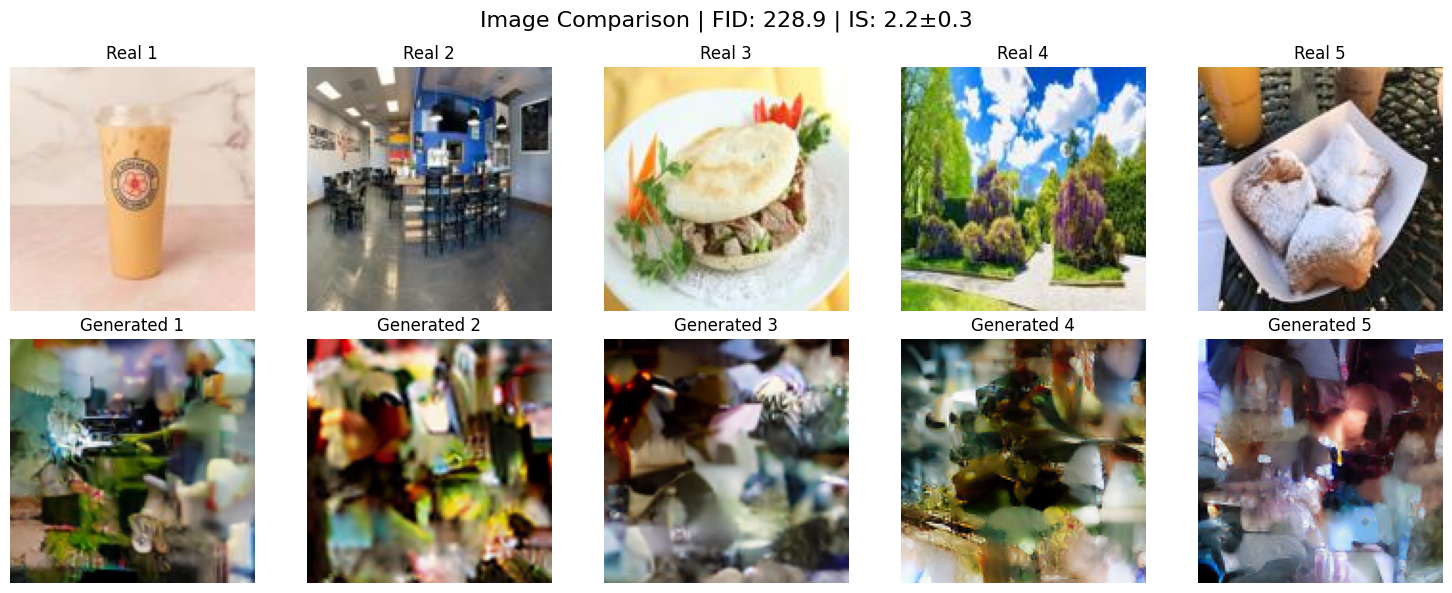

In [ ]:
# --- Create Preview ---
print("Creating preview images...")
os.makedirs("eval", exist_ok=True)

# Use first N_PREVIEW samples
preview_real = real_imgs_all[:N_PREVIEW]
preview_captions = captions[:N_PREVIEW]

# Generate preview images
preview_fake = generate_images(
    captions=preview_captions,
    unet=unet,
    tokenizer=tokenizer,
    text_encoder=text_encoder,
    batch_size=N_PREVIEW  # Process all at once
)

# Save preview images
real_preview = (preview_real.cpu() + 1) / 2
fake_preview = (preview_fake.cpu() + 1) / 2

tv_utils.save_image(real_preview, "eval/grid_real.png", nrow=N_PREVIEW, normalize=True)
tv_utils.save_image(fake_preview, "eval/grid_gen.png", nrow=N_PREVIEW, normalize=True)

# Create comparison figure
fig, axes = plt.subplots(2, N_PREVIEW, figsize=(15, 6))

for i in range(N_PREVIEW):
    # Real images
    axes[0, i].imshow(real_preview[i].permute(1, 2, 0).numpy())
    axes[0, i].set_title(f"Real {i+1}")
    axes[0, i].axis("off")

    # Generated images
    axes[1, i].imshow(fake_preview[i].permute(1, 2, 0).numpy())
    axes[1, i].set_title(f"Generated {i+1}")
    axes[1, i].axis("off")

plt.suptitle(f"Image Comparison | FID: {fid_score:.1f} | IS: {isc_mean:.1f}±{isc_std:.1f}", fontsize=16)
plt.tight_layout()
plt.savefig("eval/comparison.png", dpi=150, bbox_inches="tight")
print("Saved comparison grid to eval/comparison.png")